# 2. Análisis Bivariado — Relaciones Monótonas variable → target

**Objetivo:** detectar, para cada variable numérica, si la probabilidad de cada clase
(`GALAXY` / `QSO` / `STAR`) varía de forma **monótona a lo largo de toda la distribución** de la variable.

Como el target es multiclase, se usa un enfoque **one-vs-rest tipo *event-rate* / WoE**:

1. Cada variable se discretiza en **deciles** (`qcut`, q=10).
2. Para cada decil se calcula `P(clase | decil)` = proporción de cada clase dentro del bin.
3. Si esa probabilidad crece (o decrece) de forma sostenida a lo largo de los deciles,
   existe una **relación monótona** entre la variable y esa clase.
4. Se cuantifica con la **correlación de Spearman** (signo = dirección, |ρ| = fuerza), robusta a
   transformaciones monótonas y a outliers.

**Dataset:** Playground Series S6E6

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

In [2]:
train = pd.read_csv("../data/train.csv")

TARGET      = "class"
CLASS_ORDER = ["GALAXY", "QSO", "STAR"]
PALETTE     = {"GALAXY": "steelblue", "QSO": "tomato", "STAR": "goldenrod"}

# Indices de color (mismas features derivadas que en el EDA)
colores = {"u-g": ("u", "g"), "g-r": ("g", "r"), "r-i": ("r", "i"), "i-z": ("i", "z")}
for nombre, (a, b) in colores.items():
    train[nombre] = train[a] - train[b]

# Variables numericas a analizar (crudas + colores). Se excluyen id, alpha, delta
# por aportar poca senal de clase, pero se pueden agregar si se desea.
numericas = ["u", "g", "r", "i", "z", "redshift"] + list(colores.keys())

# Tasa base (prior) de cada clase: referencia para los graficos
base_rate = train[TARGET].value_counts(normalize=True).reindex(CLASS_ORDER)
print("Tasa base por clase:")
print((base_rate * 100).round(2).astype(str) + " %")
print(f"\nVariables a analizar ({len(numericas)}): {numericas}")

Tasa base por clase:
class
GALAXY    65.38 %
QSO       20.29 %
STAR      14.33 %
Name: proportion, dtype: object

Variables a analizar (10): ['u', 'g', 'r', 'i', 'z', 'redshift', 'u-g', 'g-r', 'r-i', 'i-z']


## 1. Helper — `P(clase | decil)`

Discretiza una variable en `q` deciles y devuelve, por bin, la proporción de cada clase
y el valor central (mediana) de la variable en ese bin.

In [3]:
def tasa_clase_por_decil(df, var, q=10):
    """Devuelve un DataFrame indexado por decil con P(clase|decil) y la mediana de la variable."""
    binned = pd.qcut(df[var], q=q, duplicates="drop")
    g = df.groupby(binned, observed=True)
    props = (
        g[TARGET].value_counts(normalize=True)
                 .unstack(fill_value=0)
                 .reindex(columns=CLASS_ORDER, fill_value=0)
    )
    props["_mediana"] = g[var].median().values
    props = props.reset_index(drop=True)          # indice = numero de decil 0..q-1
    props.index.name = "decil"
    return props

## 2. Curvas `P(clase | decil)` por variable

Cada panel muestra una línea por clase: la proporción de esa clase a lo largo de los deciles de la variable.
Las líneas punteadas horizontales son la **tasa base** de cada clase. Una curva que sube o baja de forma
sostenida (sin cambiar de dirección) indica **relación monótona** con esa clase.

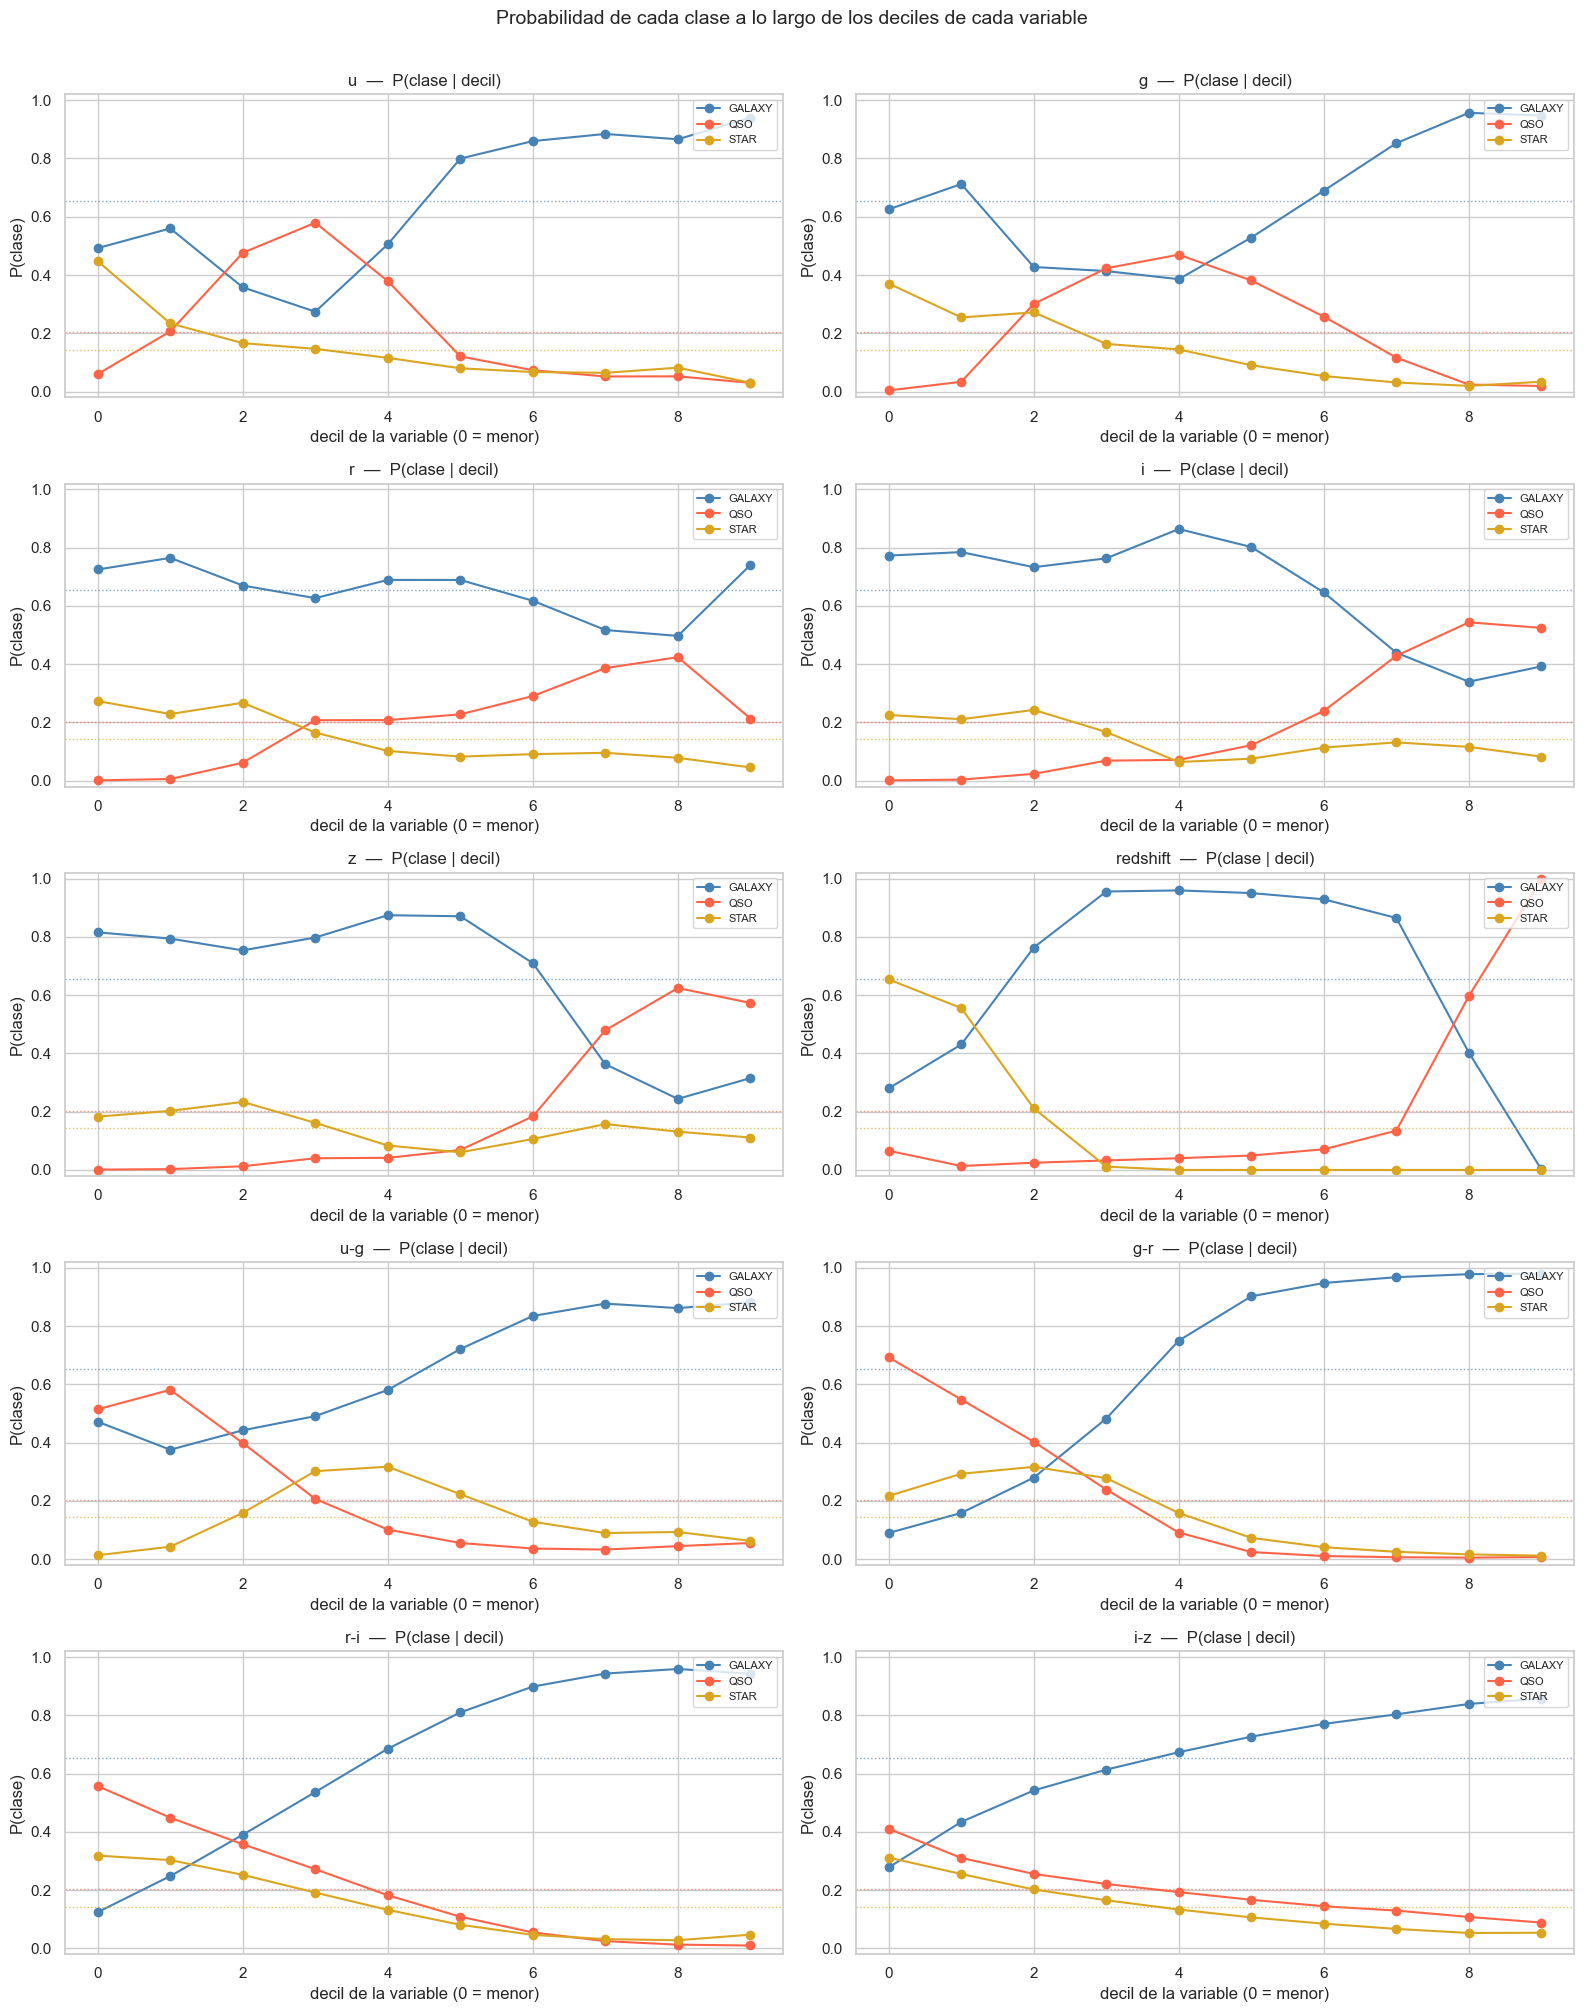

In [4]:
ncols = 2
nrows = int(np.ceil(len(numericas) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))

for ax, var in zip(axes.flat, numericas):
    props = tasa_clase_por_decil(train, var)
    for cls in CLASS_ORDER:
        ax.plot(props.index, props[cls], marker="o", color=PALETTE[cls], label=cls)
        ax.axhline(base_rate[cls], color=PALETTE[cls], ls=":", lw=1, alpha=0.7)
    ax.set_title(f"{var}  —  P(clase | decil)")
    ax.set_xlabel("decil de la variable (0 = menor)")
    ax.set_ylabel("P(clase)")
    ax.set_ylim(-0.02, 1.02)
    ax.legend(fontsize=8, loc="upper right")

for ax in axes.flat[len(numericas):]:
    ax.set_visible(False)

plt.suptitle("Probabilidad de cada clase a lo largo de los deciles de cada variable", fontsize=14, y=1.005)
plt.tight_layout()
plt.show()

## 3. Cuantificación de la monotonía (Spearman)

Para cada par (variable × clase) se calculan dos correlaciones de Spearman:

- **ρ (raw)**: entre el valor crudo de la variable y el indicador binario `1[clase]` (one-vs-rest)
  sobre todas las filas. Mide la tendencia monótona a nivel individuo.
- **ρ (decil)**: entre el índice de decil y `P(clase | decil)`. Mide cuán monótona es la **curva agregada**
  del panel anterior (|ρ_decil| ≈ 1 ⇒ curva casi perfectamente monótona).

In [5]:
filas = []
for var in numericas:
    props = tasa_clase_por_decil(train, var)
    for cls in CLASS_ORDER:
        y_bin = (train[TARGET] == cls).astype(int)
        rho_raw, _   = spearmanr(train[var], y_bin)
        rho_decil, _ = spearmanr(props.index, props[cls])
        filas.append({
            "variable": var,
            "clase": cls,
            "rho_raw": rho_raw,
            "rho_decil": rho_decil,
            "abs_raw": abs(rho_raw),
        })

spearman = pd.DataFrame(filas)

def etiqueta(row, umbral=0.3):
    if row["abs_raw"] < umbral:
        return "debil / no monotona"
    return "monotona +" if row["rho_raw"] > 0 else "monotona -"

spearman["relacion"] = spearman.apply(etiqueta, axis=1)

print("Relaciones monotonas mas fuertes (|rho_raw| descendente):")
spearman.sort_values("abs_raw", ascending=False).head(15).round(3)

Relaciones monotonas mas fuertes (|rho_raw| descendente):


,variable,clase,rho_raw,rho_decil,abs_raw,relacion
21,g-r,GALAXY,0.687,1.000,0.687,monotona +
24,r-i,GALAXY,0.599,0.964,0.599,monotona +
16,redshift,QSO,0.573,0.818,0.573,monotona +
22,g-r,QSO,-0.552,-0.964,0.552,monotona -
17,redshift,STAR,-0.542,-0.815,0.542,monotona -
13,z,QSO,0.533,0.988,0.533,monotona +
10,i,QSO,0.480,0.988,0.480,monotona +
25,r-i,QSO,-0.451,-1.000,0.451,monotona -
19,u-g,QSO,-0.443,-0.830,0.443,monotona -
0,u,GALAXY,0.399,0.842,0.399,monotona +


## 4. Resumen visual — heatmap variable × clase

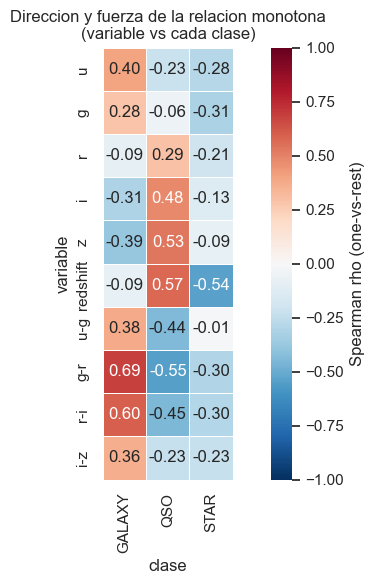

In [6]:
pivot = spearman.pivot(index="variable", columns="clase", values="rho_raw").reindex(columns=CLASS_ORDER)
pivot = pivot.reindex(numericas)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.5, square=True, ax=ax,
            cbar_kws={"label": "Spearman rho (one-vs-rest)"})
ax.set_title("Direccion y fuerza de la relacion monotona\n(variable vs cada clase)", fontsize=12)
plt.tight_layout()
plt.show()

In [7]:
# Tabla compacta: solo relaciones flaggeadas como monotonas (|rho_raw| >= 0.3)
monotonas = (spearman[spearman["relacion"] != "debil / no monotona"]
             .sort_values(["clase", "abs_raw"], ascending=[True, False])
             [["clase", "variable", "rho_raw", "rho_decil", "relacion"]])
print(f"Pares (variable, clase) con relacion monotona (|rho| >= 0.3): {len(monotonas)}")
monotonas.round(3).reset_index(drop=True)

Pares (variable, clase) con relacion monotona (|rho| >= 0.3): 15


,clase,variable,rho_raw,rho_decil,relacion
0,GALAXY,g-r,0.687,1.000,monotona +
1,GALAXY,r-i,0.599,0.964,monotona +
2,GALAXY,u,0.399,0.842,monotona +
3,GALAXY,z,-0.387,-0.661,monotona -
4,GALAXY,u-g,0.381,0.952,monotona +
5,GALAXY,i-z,0.363,1.000,monotona +
6,GALAXY,i,-0.307,-0.673,monotona -
7,QSO,redshift,0.573,0.818,monotona +
8,QSO,g-r,-0.552,-0.964,monotona -
9,QSO,z,0.533,0.988,monotona +


## 5. Conclusiones

- El heatmap y la tabla resumen, para cada variable numérica, **con qué clase tiene relación monótona
  y en qué dirección** (signo de ρ) a lo largo de toda su distribución.
- Se espera que **`redshift`** domine: relación monótona fuerte y limpia (P(STAR) decae con z, P(QSO) crece con z),
  visible como curvas casi perfectamente monótonas (|ρ_decil| ≈ 1).
- Las variables con **ρ_raw alto y ρ_decil cercano a ±1** son ideales como:
  - candidatas a **monotonic constraints** en modelos GBM (LightGBM/XGBoost/CatBoost), que mejoran
    generalización y robustez sin perder ajuste,
  - features con relación cuasi-lineal aprovechables por modelos lineales.
- Variables con curva **no monótona** (sube y baja) señalan relaciones donde un constraint monótono
  sería contraproducente y conviene dejar que el árbol modele libremente la interacción.